# Imports

In [1]:
import pandas as pd

INPUT_PATH = '/kaggle/input/notebooks/hayeonchung353/ds-5001-final-project-notebook-1/'
OUTPUT_PATH = '/kaggle/working/'

LIB = pd.read_csv(INPUT_PATH + 'LIB.csv')
CORPUS = pd.read_csv(INPUT_PATH + 'CORPUS.csv')
VOCAB = pd.read_csv(INPUT_PATH + 'VOCAB.csv')
BOW = pd.read_csv(INPUT_PATH + 'BOW.csv')

DTM = pd.read_csv(INPUT_PATH + 'DTM.csv', index_col='doc_id')
TFIDF = pd.read_csv(INPUT_PATH + 'TFIDF.csv', index_col='doc_id')
TFIDF_L2 = pd.read_csv(INPUT_PATH + 'TFIDF_L2.csv', index_col='doc_id')

print('LIB:', LIB.shape)
print('CORPUS:', CORPUS.shape)
print('VOCAB:', VOCAB.shape)
print('BOW:', BOW.shape)
print('DTM:', DTM.shape)
print('TFIDF:', TFIDF.shape)
print('TFIDF_L2:', TFIDF_L2.shape)

/tmp/ipykernel_57/2932827367.py:7: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  CORPUS = pd.read_csv(INPUT_PATH + 'CORPUS.csv')


LIB: (4141, 9)
CORPUS: (1376718, 11)
VOCAB: (20583, 9)
BOW: (435865, 8)
DTM: (4141, 20583)
TFIDF: (4141, 20583)
TFIDF_L2: (4141, 1000)


# PCA DCM

In [2]:
from sklearn.decomposition import PCA

n_components = 10

pca = PCA(n_components=n_components, random_state=42)
PCA_DCM_array = pca.fit_transform(TFIDF_L2.values)

PCA_DCM = pd.DataFrame(
    PCA_DCM_array,
    index=TFIDF_L2.index,
    columns=[f'PC{i:02d}' for i in range(n_components)]
)
PCA_DCM.to_csv(OUTPUT_PATH + 'PCA_DCM.csv')
print('PCA_DCM shape:', PCA_DCM.shape)
PCA_DCM.head()

PCA_DCM shape: (4141, 10)


,PC00,PC01,PC02,PC03,PC04,PC05,PC06,PC07,PC08,PC09
doc_id,,,,,,,,,,
0,-0.013350,-0.057514,-0.036094,0.018237,0.062127,0.004157,-0.019669,-0.004657,0.042197,0.020203
1,0.109070,-0.036064,-0.018428,-0.042455,0.048584,0.006525,-0.053033,-0.074754,0.065323,0.051160
2,0.043493,-0.055100,-0.038804,-0.002692,0.017775,-0.009411,-0.070595,-0.017837,0.022412,-0.011603
3,0.076719,-0.000930,-0.029365,-0.077816,0.081616,-0.001234,-0.047070,-0.092484,0.042788,-0.038897
4,0.229085,0.059210,0.006329,0.097686,0.054900,-0.033082,-0.030996,-0.024926,-0.029412,-0.020290


# PCA Loadings

In [3]:
PCA_LOADINGS = pd.DataFrame(
    pca.components_,
    index=[f'PC{i:02d}' for i in range(n_components)],
    columns=TFIDF_L2.columns
)
PCA_LOADINGS.to_csv(OUTPUT_PATH + 'PCA_LOADINGS.csv')
print('PCA_LOADINGS shape:', PCA_LOADINGS.shape)

print('\nTop 5 positive terms for PC00:')
print(PCA_LOADINGS.loc['PC00'].sort_values(ascending=False).head(5))

print('\nTop 5 negative terms for PC01:')
print(PCA_LOADINGS.loc['PC01'].sort_values(ascending=True).head(5))

PCA_LOADINGS shape: (10, 1000)

Top 5 positive terms for PC00:
la         0.435716
lyrics     0.168613
de         0.131663
snippet    0.108787
mi         0.064922
Name: PC00, dtype: float64

Top 5 negative terms for PC01:
again   -0.106172
never   -0.096642
her     -0.090973
she     -0.087252
him     -0.080442
Name: PC01, dtype: float64


# PCA Visualization 1

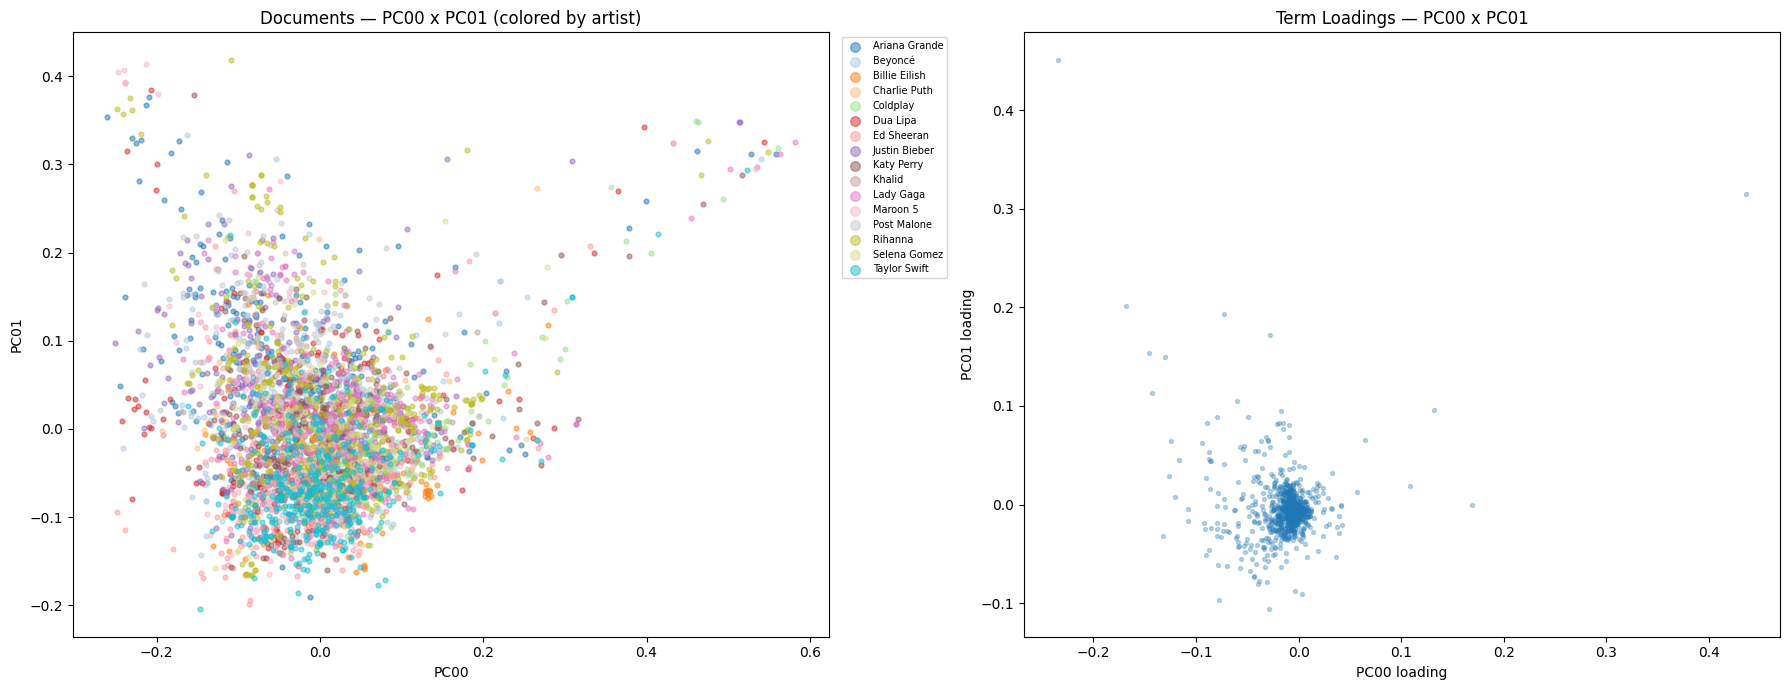

In [5]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
# Merge DCM with LIB for artist coloring
plot_df = PCA_DCM.join(LIB.set_index('doc_id')[['artist']], how='left')
artists = plot_df['artist'].fillna('Unknown')
unique_artists = sorted(artists.unique())
color_map = {a: cm.tab20(i / len(unique_artists)) for i, a in enumerate(unique_artists)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Documents in PC00 x PC01 space
ax = axes[0]
for artist in unique_artists:
    mask = artists == artist
    ax.scatter(plot_df.loc[mask, 'PC00'], plot_df.loc[mask, 'PC01'],
               label=artist, alpha=0.5, s=12, color=color_map[artist])
ax.set_xlabel('PC00')
ax.set_ylabel('PC01')
ax.set_title('Documents — PC00 x PC01 (colored by artist)')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01, 1), loc='upper left')

# Term loadings in PC00 x PC01 space
ax2 = axes[1]
ax2.scatter(PCA_LOADINGS.loc['PC00'], PCA_LOADINGS.loc['PC01'], alpha=0.3, s=8)
ax2.set_xlabel('PC00 loading')
ax2.set_ylabel('PC01 loading')
ax2.set_title('Term Loadings — PC00 x PC01')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'pca_viz1.png', dpi=150, bbox_inches='tight')
plt.show()

# PCA Visualization 2

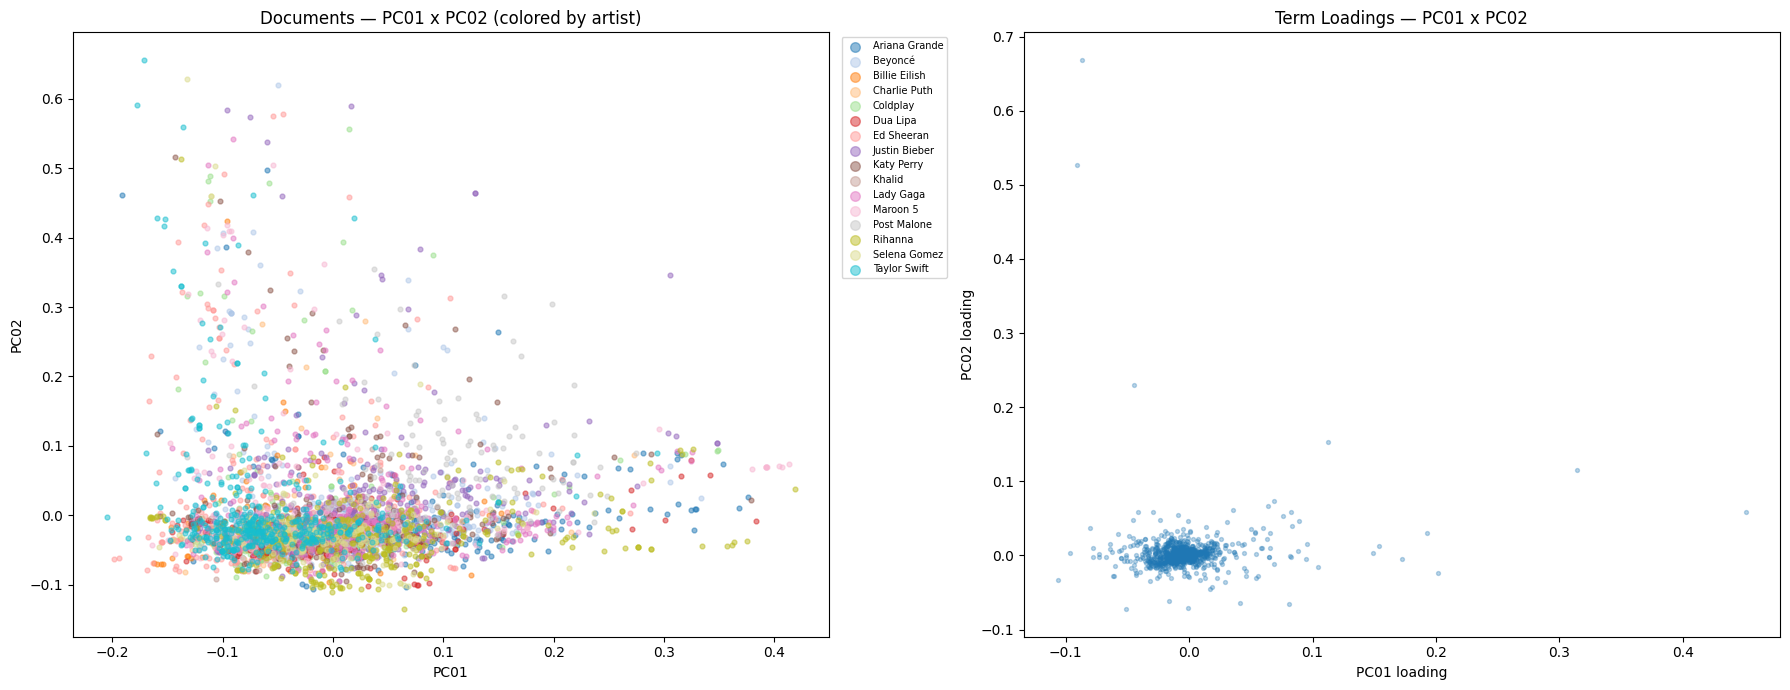

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for artist in unique_artists:
    mask = artists == artist
    ax.scatter(plot_df.loc[mask, 'PC01'], plot_df.loc[mask, 'PC02'],
               label=artist, alpha=0.5, s=12, color=color_map[artist])
ax.set_xlabel('PC01')
ax.set_ylabel('PC02')
ax.set_title('Documents — PC01 x PC02 (colored by artist)')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.01, 1), loc='upper left')

ax2 = axes[1]
ax2.scatter(PCA_LOADINGS.loc['PC01'], PCA_LOADINGS.loc['PC02'], alpha=0.3, s=8)
ax2.set_xlabel('PC01 loading')
ax2.set_ylabel('PC02 loading')
ax2.set_title('Term Loadings — PC01 x PC02')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'pca_viz2.png', dpi=150, bbox_inches='tight')
plt.show()

# LDA Topic + LDA THETA

In [7]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 20

# Filter DTM to noun + verb non-stopword terms only
nv_terms = VOCAB[
    VOCAB['max_pos_group'].isin(['noun', 'verb']) &
    (VOCAB['stop'] == False)
]['term_str'].tolist()
nv_terms = [t for t in nv_terms if t in DTM.columns]
DTM_NV = DTM[nv_terms]

lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method='online',
    random_state=42
)
LDA_THETA_array = lda.fit_transform(DTM_NV)

# THETA — document-topic matrix
LDA_THETA = pd.DataFrame(
    LDA_THETA_array,
    index=DTM_NV.index,
    columns=[f'T{i:02d}' for i in range(n_topics)]
)
LDA_THETA.to_csv(OUTPUT_PATH + 'LDA_THETA.csv')
print('LDA_THETA shape:', LDA_THETA.shape)
LDA_THETA.head()

LDA_THETA shape: (4141, 20)


,T00,T01,T02,T03,T04,T05,T06,T07,T08,T09,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19
doc_id,,,,,,,,,,,,,,,,,,,,
0,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.817376,0.171232,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633,0.000633
1,0.000286,0.000286,0.000286,0.000286,0.000286,0.172271,0.000286,0.000286,0.081558,0.653387,0.000286,0.088213,0.000286,0.000286,0.000286,0.000286,0.000286,0.000286,0.000286,0.000286
2,0.000588,0.000588,0.000588,0.000588,0.000588,0.000588,0.000588,0.000588,0.000588,0.000588,0.000588,0.113554,0.000588,0.000588,0.000588,0.000588,0.875857,0.000588,0.000588,0.000588
3,0.000562,0.000562,0.000562,0.000562,0.000562,0.000562,0.852874,0.000562,0.000562,0.000562,0.000562,0.113650,0.023925,0.000562,0.000562,0.000562,0.000562,0.000562,0.000562,0.000562
4,0.000368,0.000368,0.212728,0.000368,0.000368,0.000368,0.000368,0.000368,0.000368,0.000368,0.000368,0.177386,0.000368,0.000368,0.000368,0.000368,0.603635,0.000368,0.000368,0.000368


# LDA PHI

In [8]:
LDA_PHI = pd.DataFrame(
    lda.components_ / lda.components_.sum(axis=1, keepdims=True),
    index=[f'T{i:02d}' for i in range(n_topics)],
    columns=DTM_NV.columns
)
LDA_PHI.to_csv(OUTPUT_PATH + 'LDA_PHI.csv')
print('LDA_PHI shape:', LDA_PHI.shape)

# Top 5 words for the 5 most prominent topics by mean document weight
topic_means = LDA_THETA.mean().sort_values(ascending=False)
print('\nTop 5 words for top 5 topics by mean document weight:\n')
for topic in topic_means.head(5).index:
    top_words = LDA_PHI.loc[topic].sort_values(ascending=False).head(5).index.tolist()
    print(f'  {topic}: {chr(44)+chr(32)}'.join(top_words))

LDA_PHI shape: (20, 16168)

Top 5 words for top 5 topics by mean document weight:

i'm  T09: , love  T09: , don't  T09: , know  T09: , baby
i'll  T16: , it's  T16: , come  T16: , home  T16: , have
been  T05: , life  T05: , i've  T05: , eyes  T05: , see
i'm  T04: , hey  T04: , tonight  T04: , body  T04: , man
we're  T06: , gonna  T06: , it's  T06: , i'd  T06: , get


# LDA + PCA Visualization

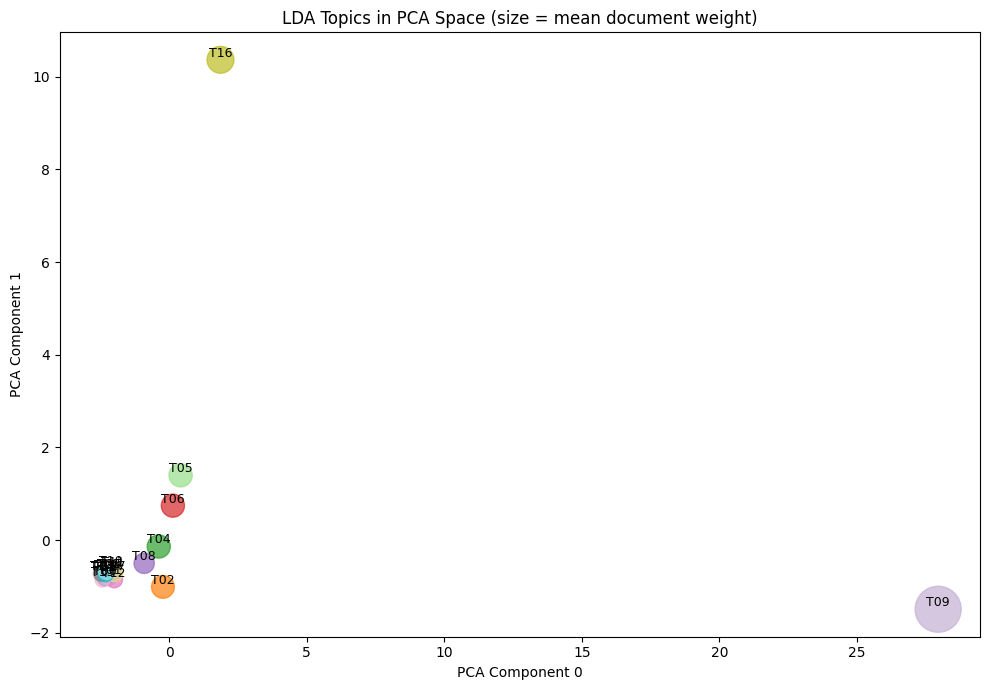

In [9]:
from sklearn.decomposition import PCA as PCA2

# Transpose as I want topics as rows, documents as features
pca_lda = PCA2(n_components=2, random_state=42)
theta_pca = pca_lda.fit_transform(LDA_THETA.T.values)  

topic_means_val = LDA_THETA.mean().values  
sizes = (topic_means_val / topic_means_val.max()) * 1000 + 100

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(theta_pca[:, 0], theta_pca[:, 1],
           s=sizes, alpha=0.7,
           c=range(n_topics), cmap='tab20')

for i, label in enumerate([f'T{i:02d}' for i in range(n_topics)]):
    ax.annotate(label, (theta_pca[i, 0], theta_pca[i, 1]),
                fontsize=9, ha='center', va='bottom')

ax.set_xlabel('PCA Component 0')
ax.set_ylabel('PCA Component 1')
ax.set_title('LDA Topics in PCA Space (size = mean document weight)')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'lda_pca_viz.png', dpi=150, bbox_inches='tight')
plt.show()

# Sentiment VOCAB_SENT

In [10]:
import nltk
nltk.download('opinion_lexicon')
from nltk.corpus import opinion_lexicon

pos_words = set(opinion_lexicon.positive())
neg_words = set(opinion_lexicon.negative())

# VOCAB_SENT
VOCAB_SENT = VOCAB[['term_str']].copy()
VOCAB_SENT['sentiment'] = VOCAB_SENT['term_str'].apply(
    lambda w: 1 if w in pos_words else (-1 if w in neg_words else 0)
)
VOCAB_SENT = VOCAB_SENT[VOCAB_SENT['sentiment'] != 0].copy()
VOCAB_SENT.to_csv(OUTPUT_PATH + 'VOCAB_SENT.csv', index=False)
print('VOCAB_SENT observations:', len(VOCAB_SENT))
print('Positive terms:', (VOCAB_SENT['sentiment'] == 1).sum())
print('Negative terms:', (VOCAB_SENT['sentiment'] == -1).sum())
VOCAB_SENT.head()

VOCAB_SENT observations: 2077
Positive terms: 712
Negative terms: 1365


[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


,term_str,sentiment
36,right,1
45,love,1
60,like,1
90,good,1
119,better,1


# Sentiment BOW_SENT

In [11]:
BOW_SENT = BOW.merge(VOCAB_SENT[['term_str', 'sentiment']], on='term_str', how='inner')
BOW_SENT.to_csv(OUTPUT_PATH + 'BOW_SENT.csv', index=False)
print('BOW_SENT observations:', len(BOW_SENT))
BOW_SENT.head()

BOW_SENT observations: 42511


,doc_id,term_str,n,doc_n,tf,i,idf,tfidf,sentiment
0,0,easy,4,189,0.021164,156,4.730361,0.100113,1
1,0,hard,2,189,0.010582,445,3.218102,0.034054,-1
2,0,haunt,1,189,0.005291,20,7.693835,0.040708,-1
3,0,loud,1,189,0.005291,119,5.120946,0.027095,-1
4,0,love,1,189,0.005291,2042,1.019996,0.005397,1


# Sentiment DOC_SENT

In [12]:
DOC_SENT = BOW_SENT.groupby('doc_id').agg(
    sentiment_mean=('sentiment', 'mean'),
    sentiment_sum=('sentiment', 'sum'),
    n_sentiment_words=('sentiment', 'count')
).reset_index()

DOC_SENT = DOC_SENT.merge(LIB[['doc_id', 'artist', 'year']], on='doc_id', how='left')
DOC_SENT.to_csv(OUTPUT_PATH + 'DOC_SENT.csv', index=False)
print('DOC_SENT observations:', len(DOC_SENT))
DOC_SENT.head()

DOC_SENT observations: 4001


,doc_id,sentiment_mean,sentiment_sum,n_sentiment_words,artist,year
0,0,-0.111111,-1,9,Coldplay,2002.0
1,1,-0.555556,-5,9,Coldplay,2008.0
2,2,-0.166667,-2,12,Coldplay,2005.0
3,3,0.500000,2,4,Coldplay,2000.0
4,4,0.200000,1,5,Coldplay,2016.0


# Sentiment Plot

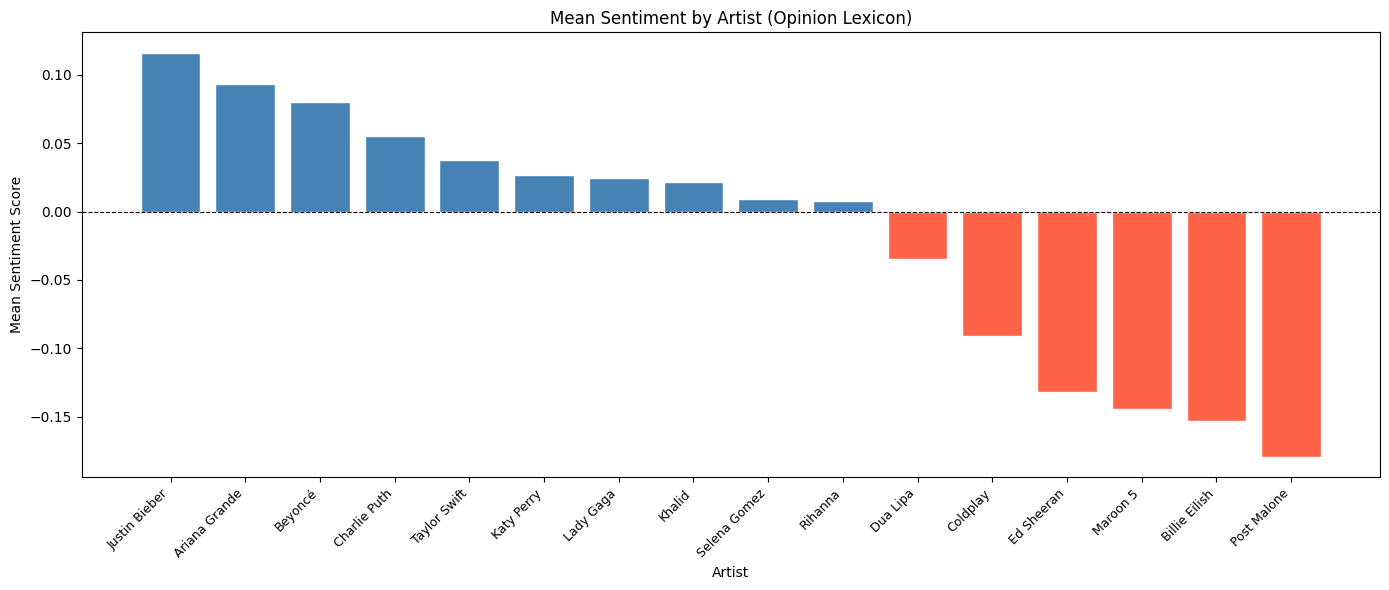

In [13]:
artist_sent = (
    DOC_SENT.groupby('artist')['sentiment_mean']
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
bar_colors = ['steelblue' if v >= 0 else 'tomato' for v in artist_sent.values]
ax.bar(artist_sent.index, artist_sent.values, color=bar_colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Artist')
ax.set_ylabel('Mean Sentiment Score')
ax.set_title('Mean Sentiment by Artist (Opinion Lexicon)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'sentiment_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Word2vec tSNE Plot 

In [14]:
from gensim.models import Word2Vec

# Build sentences: each document as an ordered list of tokens
sentences = (
    CORPUS.sort_values(['doc_id', 'line_num', 'token_num'])
    .groupby('doc_id')['term_str']
    .apply(list)
    .tolist()
)

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    seed=42,
    epochs=10
)

# VOCAB_W2V
# Filter to valid string terms only before checking the model vocab
w2v_terms = [
    t for t in VOCAB['term_str']
    if isinstance(t, str) and t in w2v_model.wv
]

VOCAB_W2V = pd.DataFrame(
    [w2v_model.wv[t] for t in w2v_terms],
    index=w2v_terms,
    columns=[f'W{i:03d}' for i in range(100)]
)
VOCAB_W2V.index.name = 'term_str'
VOCAB_W2V.to_csv(OUTPUT_PATH + 'VOCAB_W2V.csv')
print('VOCAB_W2V shape:', VOCAB_W2V.shape)
VOCAB_W2V.head()

VOCAB_W2V shape: (7731, 100)


,W000,W001,W002,W003,W004,W005,W006,W007,W008,W009,...,W090,W091,W092,W093,W094,W095,W096,W097,W098,W099
term_str,,,,,,,,,,,,,,,,,,,,,
time,0.365339,1.232617,0.890249,-1.993673,0.780437,0.230523,-1.527180,1.656937,2.396972,-0.319383,...,2.928487,-2.010085,0.130413,3.295088,0.634712,-1.396852,-1.140253,-2.123687,0.202868,0.874548
see,-2.045131,0.599461,-0.389791,-1.103443,0.138886,1.178007,0.576011,0.679130,-0.545826,0.065058,...,0.098317,-2.202430,-0.232398,-0.232737,-0.279771,-1.269609,1.064781,-2.214786,-0.614626,4.937274
not,1.080872,-1.639201,1.970420,-0.701918,-2.329964,0.622443,0.199074,-0.561833,0.641735,-0.616129,...,1.622953,-0.848480,-1.730998,0.322041,-2.322431,-0.167382,-0.669519,0.873217,-0.261770,4.175699
one,-0.503030,-0.758816,-1.277528,0.754960,1.620784,2.118004,0.362676,1.184182,1.640774,0.391855,...,-2.220503,2.136382,0.447327,-1.229877,-2.822337,-0.758729,-0.397094,-0.597454,-0.001482,3.598029
you're,-1.238010,0.662180,0.311764,0.658495,-2.396117,-0.743043,-1.518313,1.169043,-0.010864,2.460907,...,-0.583811,-2.948247,0.573935,0.752831,-0.281915,-1.584914,-2.158108,-0.856389,-1.922976,0.676075


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


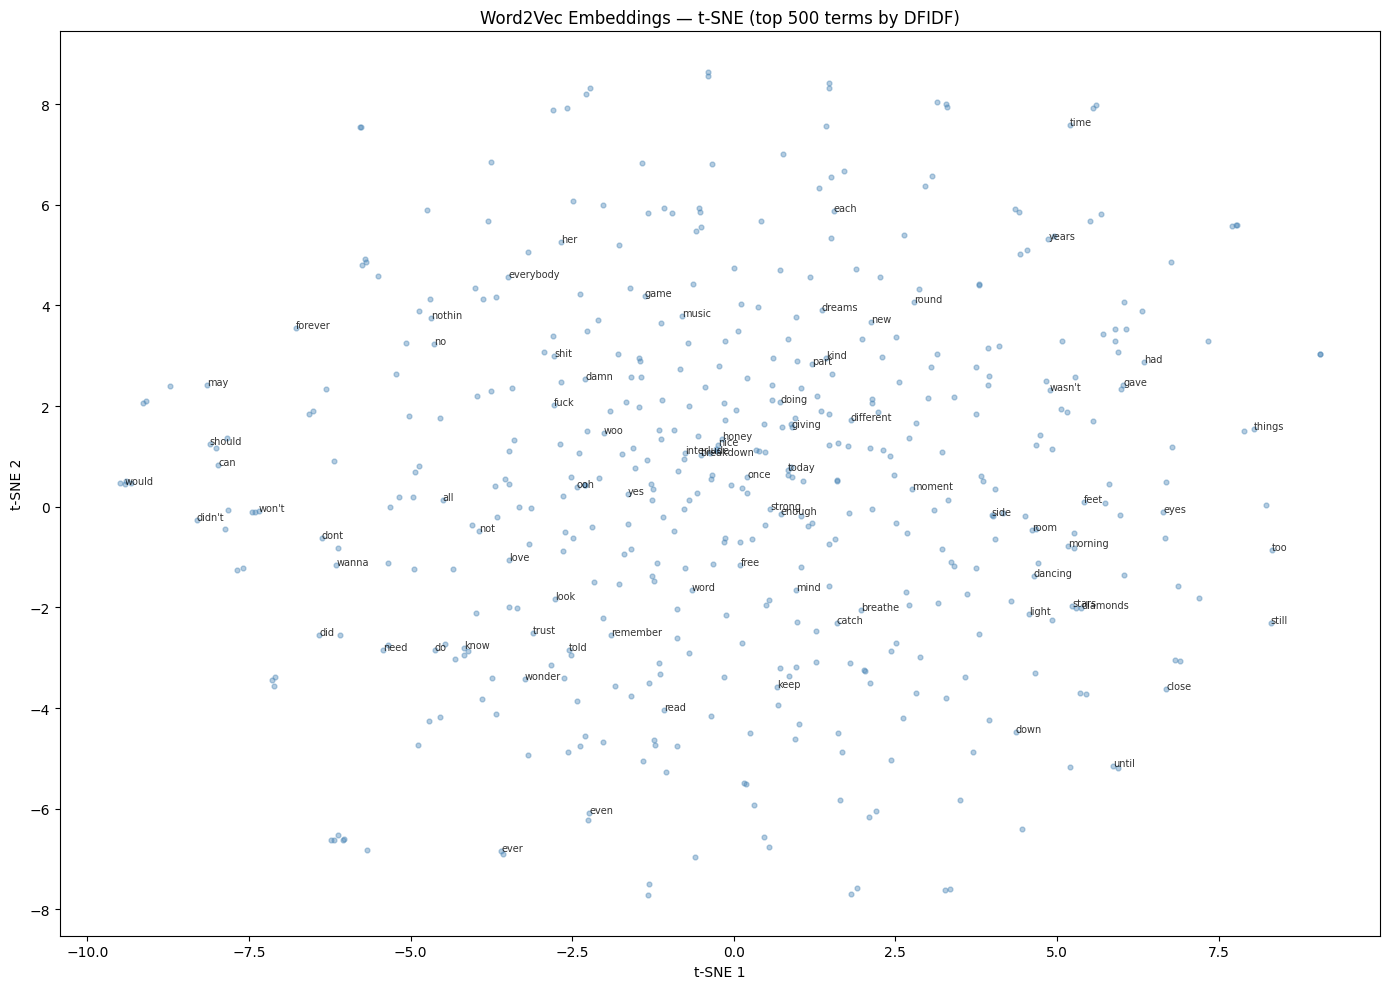

In [15]:
from sklearn.manifold import TSNE

# Top 500 non-stopword terms by DFIDF
top_terms = (
    VOCAB[VOCAB['stop'] == False]
    .sort_values('dfidf', ascending=False)
    .head(500)['term_str']
    .tolist()
)
top_terms = [t for t in top_terms if t in w2v_model.wv]

vectors_top = VOCAB_W2V.loc[top_terms].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_coords = tsne.fit_transform(vectors_top)

tsne_df = pd.DataFrame(tsne_coords, columns=['x', 'y'], index=top_terms)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(tsne_df['x'], tsne_df['y'], alpha=0.4, s=12, color='steelblue')

# Label a sample of 80 terms
label_sample = tsne_df.sample(80, random_state=42)
for term, row in label_sample.iterrows():
    ax.annotate(term, (row['x'], row['y']), fontsize=7, alpha=0.8)

ax.set_title('Word2Vec Embeddings — t-SNE (top 500 terms by DFIDF)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'w2v_tsne.png', dpi=150, bbox_inches='tight')
plt.show()